# Welltory HRV and COVID-19 Data Analysis

This notebook explores the Welltory COVID-19 dataset. The main goals are to understand the data, check data quality, clean the data, create new features, and find relationships between variables.

Data source: [Welltory HRV COVID-19 GitHub repository](https://github.com/Welltory/hrv-covid19)

This is an exploratory analysis. The results should not be used as medical advice.

## 1. Data Context and Sampling

Welltory collected this data in 2020. The participants were Welltory app users who reported a positive COVID-19 status. They recorded symptoms and heart rate variability (HRV). Some users also shared data from wearable devices.

This is a convenience sample, not a random sample. People needed to use the Welltory app and choose to share their data. Because of this, the participants may not represent all people with COVID-19.

There are also some other limits:

- Some information was reported by the users, so it may have input errors.
- Different users recorded different numbers of measurements.
- Different wearable devices collected different types of data.
- We can find relationships in the data, but we cannot prove cause and effect.

Each file has a different observation level. For example, `participants.csv` has one row for each user, while `hrv_measurements.csv` has one row for each HRV measurement.

In [66]:
from pathlib import Path
from urllib.error import URLError
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

REPO_RAW = "https://raw.githubusercontent.com/Welltory/hrv-covid19/master/data"
LOCAL_CANDIDATES = [Path("data"), Path("hrv-covid19/data")]
FILES = [
    "participants.csv", "hrv_measurements.csv", "heart_rate.csv",
    "wearables.csv", "sleep.csv", "blood_pressure.csv",
    "surveys.csv", "weather.csv", "scales_description.csv"
]

def load_csv(filename):
    for folder in LOCAL_CANDIDATES:
        path = folder / filename
        if path.exists():
            return pd.read_csv(path)
    return pd.read_csv(f"{REPO_RAW}/{filename}")

tables = {Path(name).stem: load_csv(name) for name in FILES}
print(f"Loaded {len(tables)} tables.")

Loaded 9 tables.


## 2. Understand the Data

| Table | What one row means | Main information |
|---|---|---|
| `participants` | one participant | gender, age group, location, height, weight, and symptom onset date |
| `hrv_measurements` | one HRV measurement | heart rate, HRV values, and self-reported feelings |
| `heart_rate` | one heart rate record | heart rate and whether the user was resting |
| `wearables` | one user on one day | pulse, steps, distance, calories, temperature, and SpO2 |
| `sleep` | one sleep record | sleep duration, sleep stages, and pulse during sleep |
| `blood_pressure` | one blood pressure record | systolic pressure, diastolic pressure, and other indexes |
| `surveys` | one survey answer | survey type, date, value, and answer text |
| `weather` | one user on one day | temperature, pressure, rain, humidity, and clouds |
| `scales_description` | one survey value | explanation of survey codes and values |

HRV features:

- `bpm`: heart beats per minute.
- `meanrr`: average time between heart beats.
- `sdnn`: overall variation between heart beats.
- `rmssd`: short-term variation between heart beats.
- `pnn50`: percent of nearby heart beat intervals that differ by more than 50 milliseconds.
- `lf`, `hf`, and `vlf`: HRV power in different frequency ranges.
- `lfhf`: the ratio of LF to HF.
- `total_power`: total HRV power.
- `how_feel`, `how_mood`, and `how_sleep`: answers reported by the user after a measurement.

Information are gathered here: https://github.com/Welltory/hrv-covid19/blob/master/datatypes.md

In [67]:
def profile_table(name, df):
    return {
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "unique_users": df["user_code"].nunique() if "user_code" in df else np.nan,
        "exact_duplicate_rows": int(df.duplicated().sum()),
        "missing_cells_pct": 100 * df.isna().sum().sum() / df.size,
    }

profile = pd.DataFrame([profile_table(name, df) for name, df in tables.items()])
profile.sort_values("rows", ascending=False).reset_index(drop=True)

,table,rows,columns,unique_users,exact_duplicate_rows,missing_cells_pct
0,heart_rate,523783,4,79.00,0,0.00
1,hrv_measurements,3245,22,185.00,0,3.95
2,wearables,3098,18,79.00,0,48.22
3,surveys,2259,5,111.00,0,0.00
4,weather,1717,7,104.00,0,0.00
5,blood_pressure,721,8,28.00,0,29.54
6,sleep,425,12,10.00,0,56.33
7,participants,185,8,185.00,0,3.92
8,scales_description,148,4,NaN,0,0.00


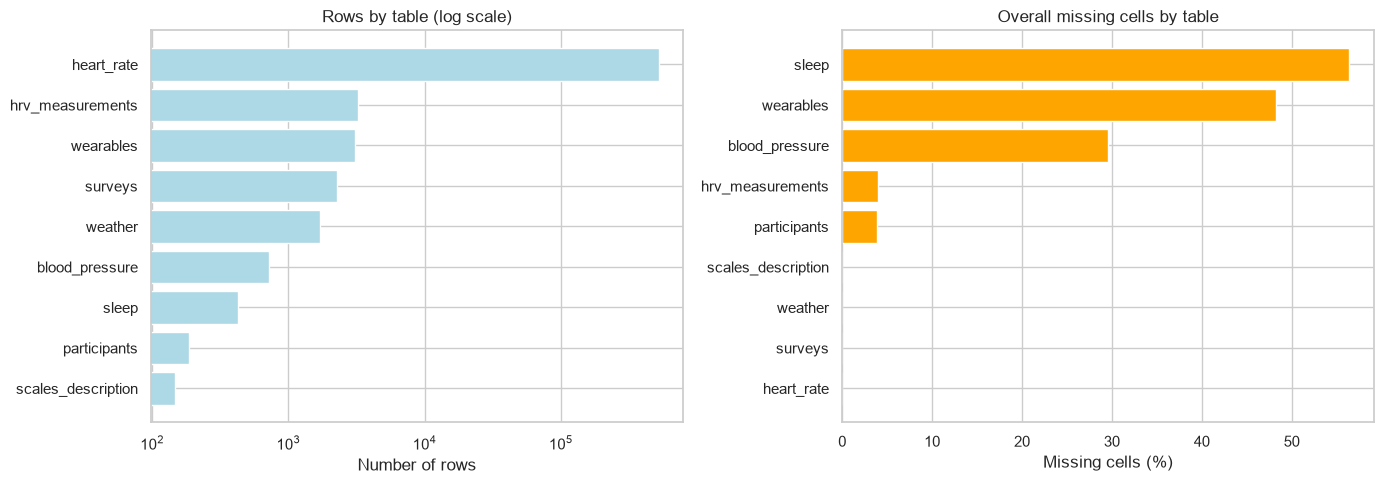

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = profile.sort_values("rows", ascending=True)
axes[0].barh(order["table"], order["rows"], color="lightblue")
axes[0].set_xscale("log")
axes[0].set_title("Rows by table (log scale)")
axes[0].set_xlabel("Number of rows")

order2 = profile.sort_values("missing_cells_pct", ascending=True)
axes[1].barh(order2["table"], order2["missing_cells_pct"], color= "orange")
axes[1].set_title("Overall missing cells by table")
axes[1].set_xlabel("Missing cells (%)")

plt.tight_layout()
plt.show()

### Data Structure

The tables have very different numbers of rows because they store different types of records. We should not directly merge all tables together. This may repeat rows and create incorrect results. Before merging daily tables, we should first group them by user and day.

In [69]:
# Show schema and sample values without printing the long rr_data strings.
for name, df in tables.items():
    print(f"\n{name}: {df.shape[0]:,} rows * {df.shape[1]} columns")
    schema = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing_n": df.isna().sum(),
        "missing_pct": 100 * df.isna().mean(),
        "unique_n": df.nunique(dropna=True),
    })
    display(schema)


participants: 185 rows * 8 columns


,dtype,missing_n,missing_pct,unique_n
user_code,str,0,0.00,185
gender,str,0,0.00,2
age_range,str,0,0.00,6
city,str,12,6.49,116
country,str,6,3.24,25
height,float64,2,1.08,54
weight,float64,0,0.00,142
symptoms_onset,str,38,20.54,74



hrv_measurements: 3,245 rows * 22 columns


,dtype,missing_n,missing_pct,unique_n
user_code,str,0,0.00,185
rr_code,str,0,0.00,3245
measurement_datetime,str,0,0.00,3241
time_of_day,str,0,0.00,4
bpm,int64,0,0.00,71
meanrr,float64,0,0.00,3134
mxdmn,float64,0,0.00,66
sdnn,float64,0,0.00,3180
rmssd,float64,0,0.00,3174
pnn50,float64,0,0.00,146



heart_rate: 523,783 rows * 4 columns


...

,dtype,missing_n,missing_pct,unique_n
user_code,str,0,0.00,111
scale,str,0,0.00,58
created_at,str,0,0.00,50
value,int64,0,0.00,6
text,str,0,0.00,65



weather: 1,717 rows * 7 columns


,dtype,missing_n,missing_pct,unique_n
user_code,str,0,0.00,104
day,str,0,0.00,169
avg_temperature_C,float64,0,0.00,1523
atmospheric_pressure,float64,0,0.00,635
precip_intensity,float64,0,0.00,205
humidity,float64,0,0.00,288
clouds,float64,0,0.00,327



scales_description: 148 rows * 4 columns


,dtype,missing_n,missing_pct,unique_n
Scale,str,0,0.00,74
Description,str,0,0.00,72
Value,int64,0,0.00,6
Meaning,str,0,0.00,99


## 3. Data Quality Assessment

I check six parts of data quality:

1. **Data profiling:** number of rows, columns, data types, and unique values.
2. **Completeness:** how many values are missing.
3. **Accuracy:** whether values are in reasonable ranges.
4. **Consistency:** whether related columns agree with each other.
5. **Integrity:** whether IDs are unique and match across tables.
6. **Lineage and provenance:** where the data came from and what changes were made.

,table,column,missing_n,missing_pct
40,wearables,average_spo2_value,3058,98.71
58,sleep,sleep_rem_duration,418,98.35
41,wearables,body_temperature_avg,3033,97.90
57,sleep,sleep_awake_duration,416,97.88
60,sleep,sleep_deep_duration,411,96.71
63,sleep,pulse_average,410,96.47
62,sleep,pulse_max,410,96.47
61,sleep,pulse_min,410,96.47
51,wearables,average_environment_exposure,2949,95.19
59,sleep,sleep_light_duration,398,93.65


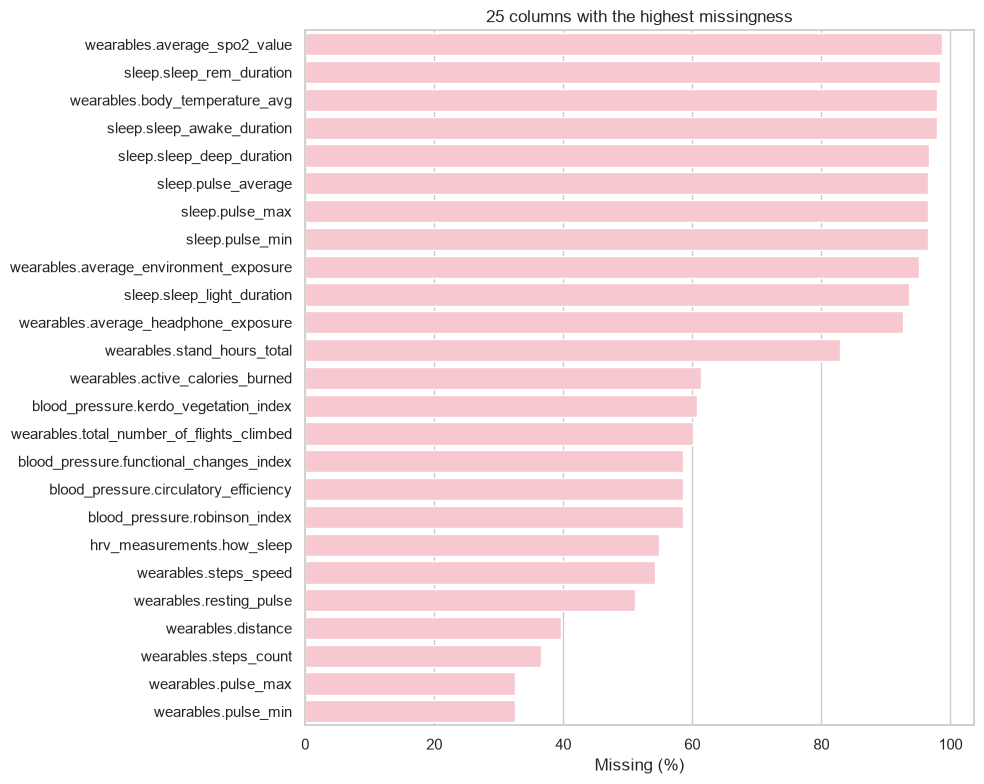

In [70]:
# Column-level completeness summary
missing_summary = pd.concat(
    [
        pd.DataFrame({
            "table": name,
            "column": df.columns,
            "missing_n": df.isna().sum().values,
            "missing_pct": (100 * df.isna().mean()).values,
        })
        for name, df in tables.items()
    ],
    ignore_index=True,
)

display(missing_summary.sort_values("missing_pct", ascending=False).head(30))

plot_missing = missing_summary.query("missing_pct > 0").sort_values("missing_pct", ascending=False).head(25)
plt.figure(figsize=(10, 8))
sns.barplot(data=plot_missing, x="missing_pct", y=plot_missing["table"] + "." + plot_missing["column"], color="pink")
plt.title("25 columns with the highest missingness")
plt.xlabel("Missing (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Handling Missing Values

I use these rules for missing values:

- I do not replace missing wearable values with zero. Zero is a real value, but missing means the device did not record the feature.
- I keep missing `how_sleep` values as missing because it is a personal survey answer.
- I replace missing `tags` with an empty string only when I count the tags.
- I use `Unknown` for missing location categories when showing the data.
- I do not guess a missing symptom onset date.
- Each analysis only uses rows that have the needed columns.

In [71]:
# Primary-key and referential-integrity checks
key_map = {
    "participants": ["user_code"],
    "hrv_measurements": ["rr_code"],
    "wearables": ["user_code", "day"],
    "weather": ["user_code", "day"],
    "sleep": ["user_code", "day"],
    "scales_description": ["Scale", "Value"],
}

participant_ids = set(tables["participants"]["user_code"])
integrity_rows = []
for name, keys in key_map.items():
    df = tables[name]
    orphan_users = int((~df["user_code"].isin(participant_ids)).sum()) if "user_code" in df else np.nan
    integrity_rows.append({
        "table": name,
        "candidate_key": " + ".join(keys),
        "duplicate_key_rows": int(df.duplicated(keys, keep=False).sum()),
        "orphan_user_rows": orphan_users,
    })

integrity = pd.DataFrame(integrity_rows)
integrity

,table,candidate_key,duplicate_key_rows,orphan_user_rows
0,participants,user_code,0,0.00
1,hrv_measurements,rr_code,0,0.00
2,wearables,user_code + day,0,0.00
3,weather,user_code + day,0,0.00
4,sleep,user_code + day,74,0.00
5,scales_description,Scale + Value,0,NaN


### Handling Duplicates

There are no exact duplicate rows in the main files. The sleep table has some users with more than one record on the same day. These rows may be different sleep periods, so I do not remove them. In the HRV table, `rr_code` is unique for every measurement.

In [72]:
# Prepare date fields and test for invalid symptom-onset entries.
participants_raw = tables["participants"].copy()
hrv_raw = tables["hrv_measurements"].copy()

participants_raw["symptoms_onset_parsed"] = pd.to_datetime(
    participants_raw["symptoms_onset"], errors="coerce"
)
hrv_raw["measurement_datetime"] = pd.to_datetime(
    hrv_raw["measurement_datetime"], errors="coerce"
)

# The study and measurements concern the 2019/2020 outbreak. Earlier years are entry errors.
valid_onset_window = participants_raw["symptoms_onset_parsed"].between(
    "2019-12-01", "2020-06-30"
)
invalid_nonmissing_onset = participants_raw[
    participants_raw["symptoms_onset"].notna() & ~valid_onset_window
][["user_code", "symptoms_onset"]]

print("Measurement date range:", hrv_raw["measurement_datetime"].min(), "to", hrv_raw["measurement_datetime"].max())
print("Invalid non-missing onset dates:", len(invalid_nonmissing_onset))
display(invalid_nonmissing_onset)

Measurement date range: 2019-12-31 06:08:29 to 2020-06-19 11:40:13
Invalid non-missing onset dates: 13


,user_code,symptoms_onset
20,1942df1c47,3/6/1999
24,1f2eb6aded,7/7/1987
29,262f55c029,11/26/1981
45,393bac62f4,4/21/2022
49,3fff7627ca,4/5/1984
62,50249775be,12/16/1982
79,638c757e73,4/1/2021
91,78cc008261,1/30/1967
94,7badc26d11,8/15/1968
102,83161408c1,1/1/1993


In [73]:
# Accuracy and consistency rules. These are screening rules, not diagnoses.
accuracy_checks = pd.DataFrame([
    {
        "rule": "Height within 120-230 cm",
        "failed_rows": int((~participants_raw["height"].between(120, 230) & participants_raw["height"].notna()).sum()),
    },
    {
        "rule": "Weight within 30-300 kg",
        "failed_rows": int((~participants_raw["weight"].between(30, 300) & participants_raw["weight"].notna()).sum()),
    },
    {
        "rule": "BPM within 30-220",
        "failed_rows": int((~hrv_raw["bpm"].between(30, 220) & hrv_raw["bpm"].notna()).sum()),
    },
    {
        "rule": "RMSSD is positive",
        "failed_rows": int((hrv_raw["rmssd"] <= 0).sum()),
    },
    {
        "rule": "Symptom onset in Dec 2019-Jun 2020",
        "failed_rows": len(invalid_nonmissing_onset),
    },
])
display(accuracy_checks)

# Internal consistency: BPM versus mean RR and total power versus component sum.
hrv_raw["bpm_from_meanrr"] = 60000 / hrv_raw["meanrr"]
hrv_raw["bpm_relative_error"] = (
    (hrv_raw["bpm"] - hrv_raw["bpm_from_meanrr"]).abs() / hrv_raw["bpm"]
)
hrv_raw["power_component_sum"] = hrv_raw[["lf", "hf", "vlf"]].sum(axis=1)
hrv_raw["power_relative_error"] = (
    (hrv_raw["total_power"] - hrv_raw["power_component_sum"]).abs()
    / hrv_raw["total_power"].replace(0, np.nan)
)

pd.DataFrame({
    "consistency_check": ["BPM vs 60,000 / meanRR", "Total power vs LF + HF + VLF"],
    "median_relative_error_pct": [
        100 * hrv_raw["bpm_relative_error"].median(),
        100 * hrv_raw["power_relative_error"].median(),
    ],
    "rows_over_5pct_error": [
        int((hrv_raw["bpm_relative_error"] > .05).sum()),
        int((hrv_raw["power_relative_error"] > .05).sum()),
    ],
})

,rule,failed_rows
0,Height within 120-230 cm,2
1,Weight within 30-300 kg,0
2,BPM within 30-220,0
3,RMSSD is positive,0
4,Symptom onset in Dec 2019-Jun 2020,13


,consistency_check,median_relative_error_pct,rows_over_5pct_error
0,"BPM vs 60,000 / meanRR",0.45,0
1,Total power vs LF + HF + VLF,0.00,0


### Data Accuracy

These checks can show values that look incorrect, but they cannot prove that every medical measurement is correct. There is no medical record in this dataset to compare with the measurements. Invalid symptom onset years are changed to missing instead of guessing the correct date.

## 4. Data Cleaning and Transformation

The following steps are used:

1. Remove exact duplicate rows.
2. Change date columns to datetime format.
3. Change impossible symptom onset dates to missing.
4. Change impossible height and weight values to missing.
5. Keep the original HRV values.
6. Create clipped versions for visualizations so a few very large values do not make the charts hard to read.
7. Use log transformation for HRV variables that are strongly right-skewed.
8. Merge HRV data with participant data by `user_code`.

I do not automatically delete all outliers. A large HRV value may be a real health measurement or a device error. I keep the original value and only use a clipped copy for some charts.

In [74]:
# Remove only exact duplicate rows from each table.
tables_clean = {name: df.drop_duplicates().copy() for name, df in tables.items()}
duplicate_actions = pd.DataFrame({
    "table": tables.keys(),
    "rows_before": [len(df) for df in tables.values()],
    "rows_after": [len(tables_clean[name]) for name in tables],
})
duplicate_actions["exact_rows_removed"] = duplicate_actions["rows_before"] - duplicate_actions["rows_after"]
duplicate_actions

,table,rows_before,rows_after,exact_rows_removed
0,participants,185,185,0
1,hrv_measurements,3245,3245,0
2,heart_rate,523783,523783,0
3,wearables,3098,3098,0
4,sleep,425,425,0
5,blood_pressure,721,721,0
6,surveys,2259,2259,0
7,weather,1717,1717,0
8,scales_description,148,148,0


In [75]:
# Clean participants.
participants = tables_clean["participants"].copy()
participants["symptoms_onset"] = pd.to_datetime(participants["symptoms_onset"], errors="coerce")
participants.loc[
    ~participants["symptoms_onset"].between("2019-12-01", "2020-06-30"),
    "symptoms_onset",
] = pd.NaT

# Treat implausible anthropometric entries as missing instead of guessing units.
participants.loc[~participants["height"].between(120, 230), "height"] = np.nan
participants.loc[~participants["weight"].between(30, 300), "weight"] = np.nan

for col in ["gender", "age_range", "city", "country"]:
    participants[col] = participants[col].fillna("Unknown").astype("category")

# New participant feature 1: BMI. Missing height remains missing rather than being imputed.
participants["bmi"] = participants["weight"] / (participants["height"] / 100) ** 2

# Clean and enrich HRV measurements.
hrv = tables_clean["hrv_measurements"].copy()
hrv["measurement_datetime"] = pd.to_datetime(hrv["measurement_datetime"], errors="coerce")
hrv["tags_was_missing"] = hrv["tags"].isna()
hrv["tags"] = hrv["tags"].fillna("")
hrv["tag_count"] = hrv["tags"].str.split(";").apply(
    lambda values: sum(bool(v.strip()) for v in values)
)
hrv["measurement_hour"] = hrv["measurement_datetime"].dt.hour
hrv["measurement_date"] = hrv["measurement_datetime"].dt.normalize()
hrv["is_weekend"] = hrv["measurement_datetime"].dt.dayofweek >= 5

# many-to-one protects against accidental row multiplication.
analysis = hrv.merge(participants, on="user_code", how="left", validate="many_to_one")

# New participant-time features 2 and 3: days from onset and interpretable phase.
analysis["days_from_onset"] = (
    analysis["measurement_date"] - analysis["symptoms_onset"]
).dt.days
analysis["covid_phase"] = pd.cut(
    analysis["days_from_onset"],
    bins=[-np.inf, -1, 14, 28, np.inf],
    labels=["Pre-onset", "Days 0–14", "Days 15–28", "Day 29+"],
)

# Transform skewed variables; log1p is defined at zero.
for col in ["rmssd", "sdnn", "lf", "hf", "vlf", "total_power", "lfhf"]:
    analysis[f"log1p_{col}"] = np.log1p(analysis[col])
    lo, hi = analysis[col].quantile([0.01, 0.99])
    analysis[f"{col}_viz"] = analysis[col].clip(lo, hi)

print("Clean analysis shape:", analysis.shape)
print("Rows with a valid symptom-onset date:", analysis["days_from_onset"].notna().sum())
display(analysis[["user_code", "rr_code", "measurement_datetime", "bmi", "days_from_onset", "covid_phase", "tag_count"]].head())

Clean analysis shape: (3245, 51)
Rows with a valid symptom-onset date: 2685


,user_code,rr_code,measurement_datetime,bmi,days_from_onset,covid_phase,tag_count
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,33.20,NaN,NaN,14
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,33.20,NaN,NaN,0
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,25.53,0.00,Days 0–14,12
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,25.53,4.00,Days 0–14,0
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,29.04,-96.00,Pre-onset,0


In [76]:
# IQR outlier report (flag only; no deletion).
outlier_rows = []
for col in ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "lf", "hf", "vlf", "lfhf", "total_power"]:
    q1, q3 = analysis[col].quantile([.25, .75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flag = ~analysis[col].between(lower, upper)
    outlier_rows.append({
        "variable": col,
        "lower_fence": lower,
        "upper_fence": upper,
        "flagged_n": int(flag.sum()),
        "flagged_pct": 100 * flag.mean(),
    })

outlier_report = pd.DataFrame(outlier_rows).sort_values("flagged_pct", ascending=False)
outlier_report

,variable,lower_fence,upper_fence,flagged_n,flagged_pct
8,lfhf,-1.95,4.32,382,11.77
6,hf,"-1,094.50","2,245.50",334,10.29
5,lf,"-1,211.00","2,421.00",291,8.97
9,total_power,"-2,809.00","6,335.00",266,8.20
7,vlf,-749.50,"1,558.50",262,8.07
3,rmssd,-21.27,112.73,195,6.01
2,sdnn,-15.15,112.14,149,4.59
4,pnn50,-28.79,64.13,127,3.91
0,bpm,41.00,105.00,25,0.77
1,meanrr,467.33,"1,201.10",12,0.37


## 5. Descriptive Statistics

This section looks at the range, average, median, and distribution of the main variables.

In [77]:
core_numeric = ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "lf", "hf", "vlf", "lfhf", "total_power"]
analysis[core_numeric].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
bpm,"3,245.00",73.26,12.20,44.00,51.00,55.00,65.00,72.00,81.00,95.80,105.00,125.00
meanrr,"3,245.00",839.60,137.42,477.73,568.58,626.76,742.49,829.10,925.93,"1,091.80","1,168.81","1,346.74"
sdnn,"3,245.00",52.49,29.37,9.52,12.82,18.33,32.59,46.92,64.41,107.40,165.38,206.63
rmssd,"3,245.00",52.81,39.35,6.34,11.70,16.83,28.98,42.87,62.48,120.24,226.64,310.80
pnn50,"3,245.00",20.62,18.59,0.00,0.00,1.00,6.06,16.16,29.29,56.57,83.84,91.92
lf,"3,245.00",927.04,"1,455.42",2.00,12.00,34.00,151.00,423.00,"1,059.00","3,533.40","7,520.20","15,522.00"
hf,"3,245.00","1,125.04","2,490.54",4.00,20.00,46.20,158.00,380.00,993.00,"4,102.80","14,204.04","33,490.00"
vlf,"3,245.00",578.23,876.68,1.00,9.00,28.00,116.00,293.00,693.00,"2,023.80","3,860.24","18,468.00"
lfhf,"3,245.00",2.40,5.75,0.03,0.08,0.16,0.40,0.86,1.97,9.85,27.12,105.62
total_power,"3,245.00","2,630.31","3,912.25",44.00,91.00,188.00,620.00,"1,387.00","2,906.00","9,443.80","21,280.08","41,118.00"


In [78]:
participant_summary = pd.DataFrame({
    "participants": [participants["user_code"].nunique()],
    "participants_with_valid_onset": [participants["symptoms_onset"].notna().sum()],
    "hrv_measurements": [len(analysis)],
    "median_measurements_per_participant": [analysis.groupby("user_code").size().median()],
    "measurement_start": [analysis["measurement_datetime"].min()],
    "measurement_end": [analysis["measurement_datetime"].max()],
})
participant_summary.T

,0
participants,185
participants_with_valid_onset,134
hrv_measurements,3245
median_measurements_per_participant,4.00
measurement_start,2019-12-31 06:08:29
measurement_end,2020-06-19 11:40:13


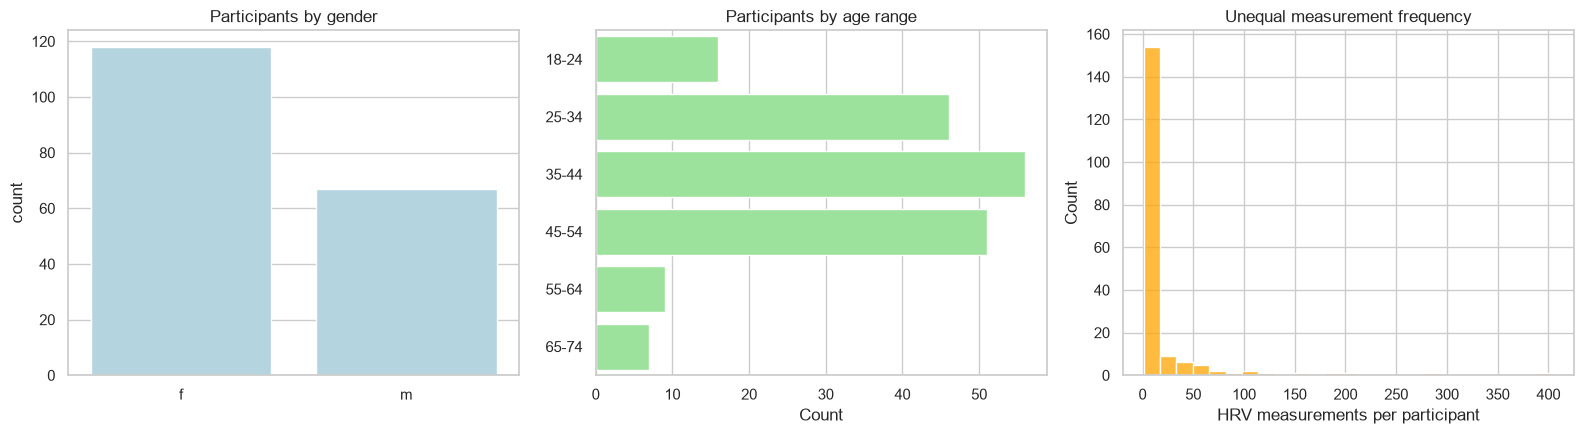

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.countplot(data=participants, x="gender", ax=axes[0], color= "lightblue")
axes[0].set_title("Participants by gender")
axes[0].set_xlabel("")

age_order = sorted(participants["age_range"].astype(str).unique())
sns.countplot(data=participants, y="age_range", order=age_order, ax=axes[1], color = "lightgreen")
axes[1].set_title("Participants by age range")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

measurements_per_user = analysis.groupby("user_code").size()
sns.histplot(measurements_per_user, bins=25, ax=axes[2], color="orange")
axes[2].set_title("Unequal measurement frequency")
axes[2].set_xlabel("HRV measurements per participant")

plt.tight_layout()
plt.show()

Some users have many more measurements than other users. If we only count rows, these users may have too much influence on the result. For the time analysis, I first calculate one median value for each user on each day.

## 6. Visual Exploration and Variable Relationships

The following charts show distributions and relationships between the main HRV variables.

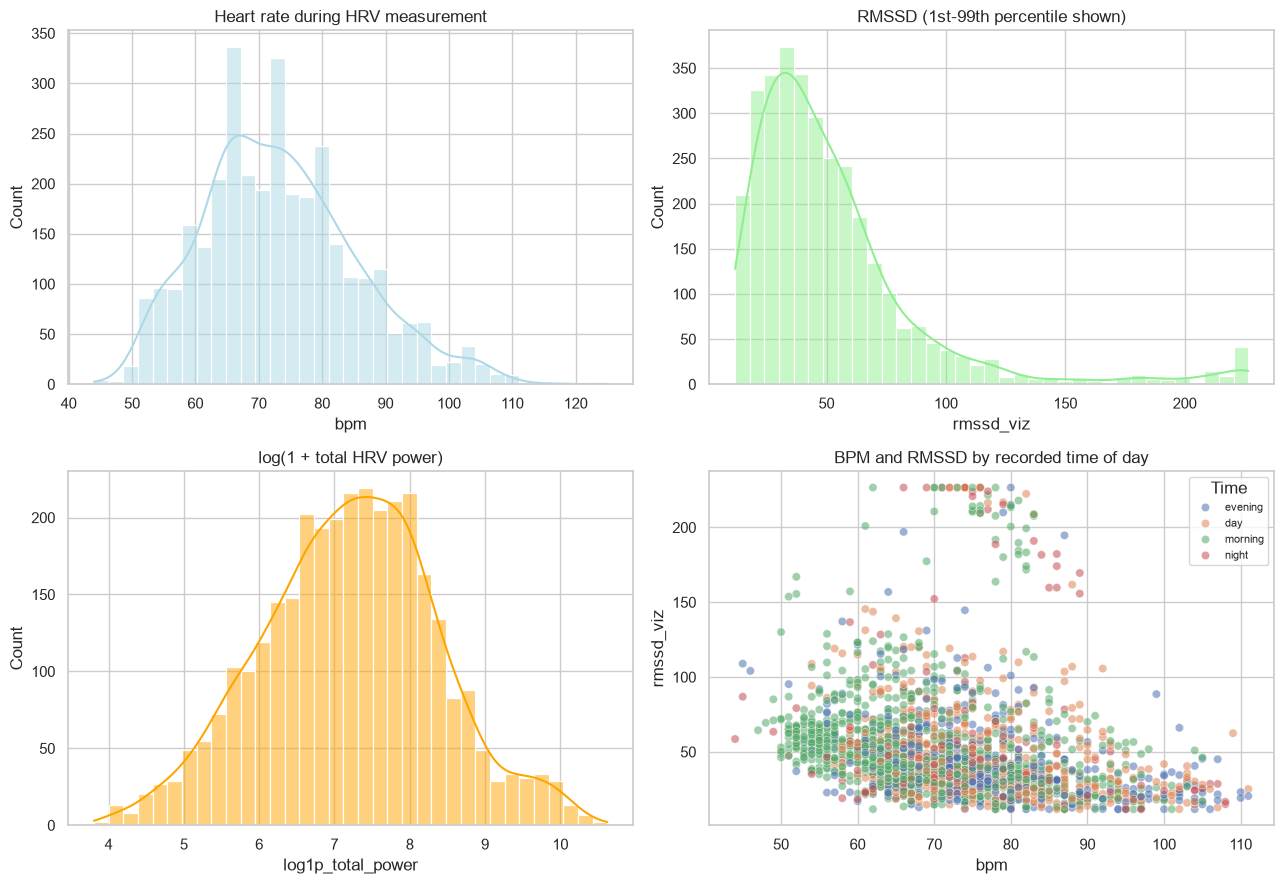

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(analysis["bpm"], bins=35, kde=True, ax=axes[0, 0], color= "lightblue")
axes[0, 0].set_title("Heart rate during HRV measurement")

sns.histplot(analysis["rmssd_viz"], bins=35, kde=True, ax=axes[0, 1], color = "lightgreen")
axes[0, 1].set_title("RMSSD (1st-99th percentile shown)")

sns.histplot(analysis["log1p_total_power"], bins=35, kde=True, ax=axes[1, 0], color= "orange")
axes[1, 0].set_title("log(1 + total HRV power)")

sns.scatterplot(
    data=analysis.sample(min(2000, len(analysis)), random_state=42),
    x="bpm", y="rmssd_viz", hue="time_of_day", alpha=.55, ax=axes[1, 1]
)
axes[1, 1].set_title("BPM and RMSSD by recorded time of day")
axes[1, 1].legend(title="Time", fontsize=8)

plt.tight_layout()
plt.show()

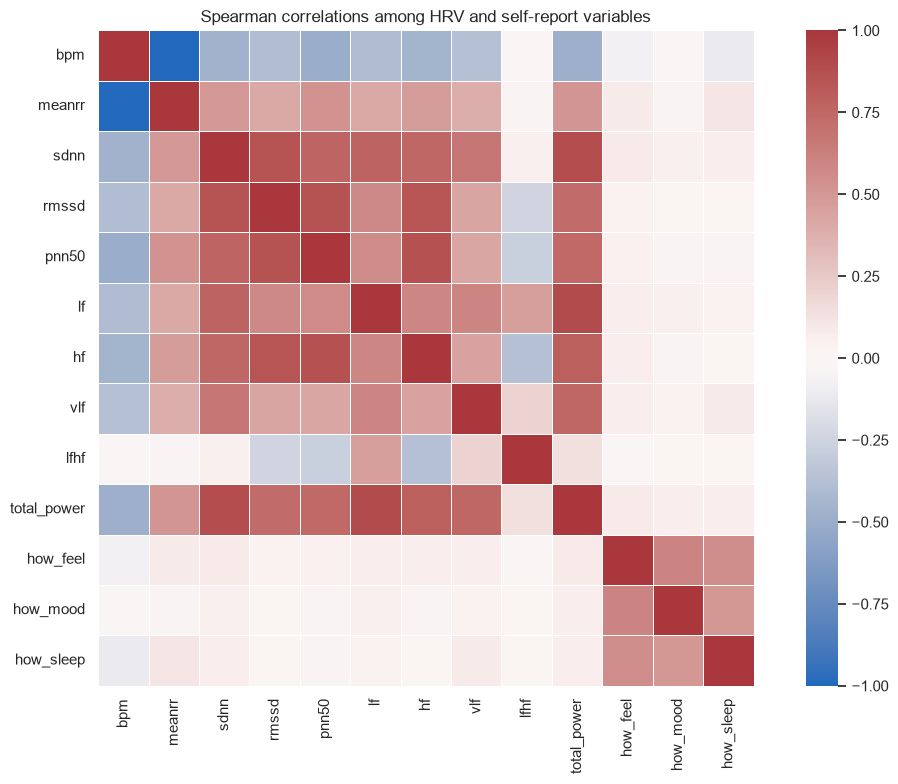

In [81]:
corr_cols = ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "lf", "hf", "vlf", "lfhf", "total_power", "how_feel", "how_mood", "how_sleep"]
corr = analysis[corr_cols].corr(method="spearman")

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="vlag", center=0, vmin=-1, vmax=1, square=True, linewidths=.4)
plt.title("Spearman correlations among HRV and self-report variables")
plt.tight_layout()
plt.show()

I use Spearman correlation because some HRV variables have skewed distributions. Correlation only shows that two variables change together. It does not mean that one variable causes the other variable.

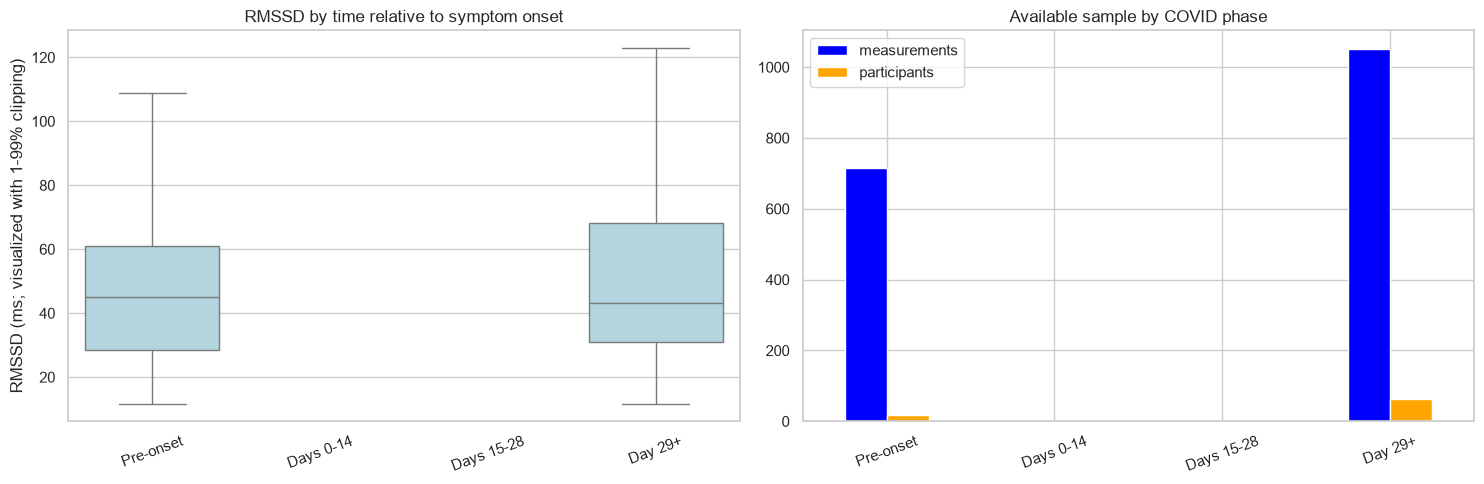

,measurements,participants
covid_phase,,
Pre-onset,714.00,19.00
Days 0-14,NaN,NaN
Days 15-28,NaN,NaN
Day 29+,"1,051.00",63.00


In [82]:
phase_order = ["Pre-onset", "Days 0-14", "Days 15-28", "Day 29+"]
phase_data = analysis.dropna(subset=["covid_phase", "rmssd"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(
    data=phase_data, x="covid_phase", y="rmssd_viz",
    order=phase_order, showfliers=False, color= "lightblue", ax=axes[0]
)
axes[0].set_title("RMSSD by time relative to symptom onset")
axes[0].set_xlabel("")
axes[0].set_ylabel("RMSSD (ms; visualized with 1-99% clipping)")
axes[0].tick_params(axis="x", rotation=20)

phase_counts = phase_data.groupby("covid_phase", observed=False).agg(
    measurements=("rr_code", "size"), participants=("user_code", "nunique")
).reindex(phase_order)
phase_counts.plot(kind="bar", ax=axes[1], color=["blue", "orange"])
axes[1].set_title("Available sample by COVID phase")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()
display(phase_counts)

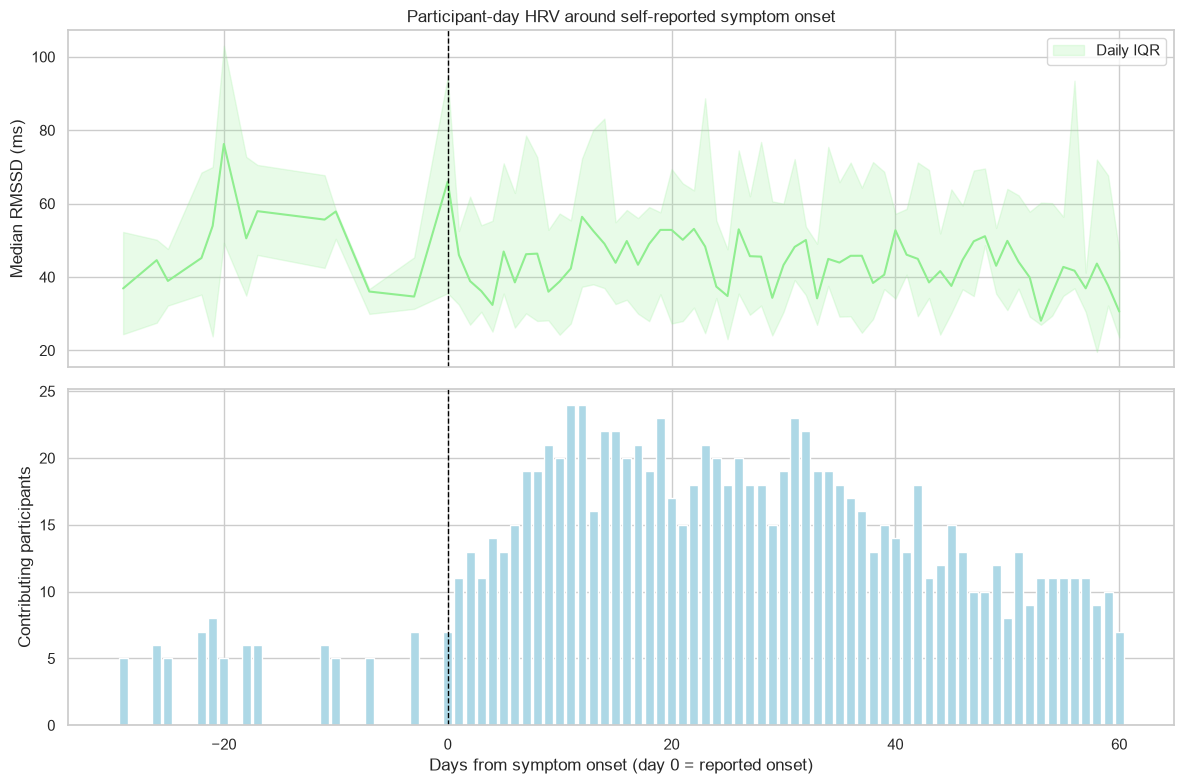

In [83]:
# Aggregate to participant-day first, then summarize across participants.
trajectory = (
    analysis.loc[analysis["days_from_onset"].between(-30, 60)]
    .groupby(["user_code", "days_from_onset"], as_index=False)
    .agg(rmssd=("rmssd", "median"), bpm=("bpm", "median"))
)

daily_summary = trajectory.groupby("days_from_onset").agg(
    rmssd_median=("rmssd", "median"),
    rmssd_q25=("rmssd", lambda x: x.quantile(.25)),
    rmssd_q75=("rmssd", lambda x: x.quantile(.75)),
    bpm_median=("bpm", "median"),
    participants=("user_code", "nunique"),
).reset_index()

# Only plot days with at least five contributing participants.
daily_plot = daily_summary.query("participants >= 5")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(daily_plot["days_from_onset"], daily_plot["rmssd_median"], color="lightgreen")
axes[0].fill_between(
    daily_plot["days_from_onset"], daily_plot["rmssd_q25"], daily_plot["rmssd_q75"],
    color = "lightgreen", alpha=.2, label="Daily IQR"
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_ylabel("Median RMSSD (ms)")
axes[0].set_title("Participant-day HRV around self-reported symptom onset")
axes[0].legend()

axes[1].bar(daily_plot["days_from_onset"], daily_plot["participants"], color= "lightblue")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_ylabel("Contributing participants")
axes[1].set_xlabel("Days from symptom onset (day 0 = reported onset)")

plt.tight_layout()
plt.show()

### Interpretation

The time chart first calculates the median for each participant on each day. This reduces the effect of users who recorded many measurements. However, different days still have different numbers of participants. The symptom onset date is also self-reported. Therefore, this chart can show a possible pattern, but it cannot prove that COVID-19 caused the HRV change.

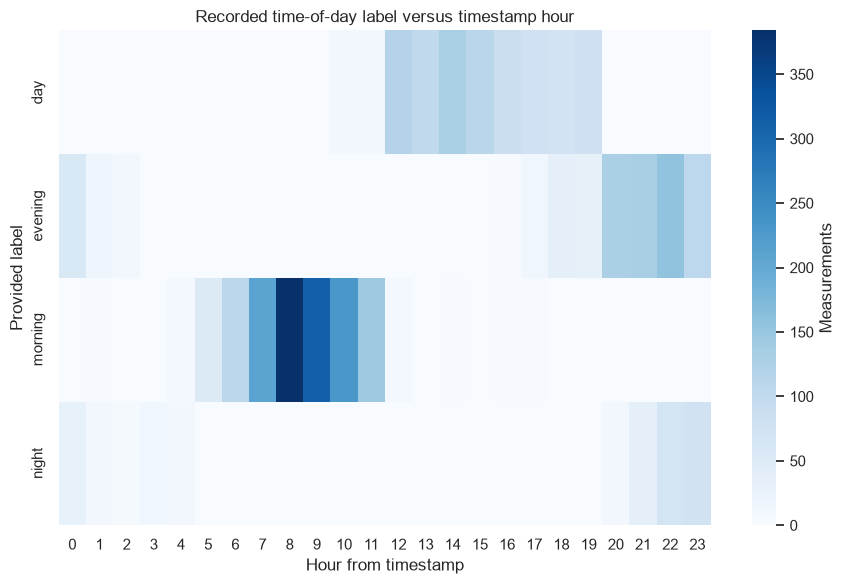

In [84]:
# Time-of-day consistency: compare the provided label to measurement hour.
hour_by_label = pd.crosstab(analysis["measurement_hour"], analysis["time_of_day"])
plt.figure(figsize=(9, 6))
sns.heatmap(hour_by_label.T, cmap="Blues", cbar_kws={"label": "Measurements"})
plt.title("Recorded time-of-day label versus timestamp hour")
plt.xlabel("Hour from timestamp")
plt.ylabel("Provided label")
plt.tight_layout()
plt.show()

The `time_of_day` label is mostly similar to the hour in the timestamp. A few records do not match exactly. The timestamp may use local time, device time, or another time setting, so I keep both the original label and the hour created from the timestamp.

## 7. Data Quality Summary

### Data Profiling

The dataset has several tables with different observation levels. The participant table can be merged with the HRV table by `user_code`. Daily tables should be grouped by user and day before merging.

### Data Completeness

The main HRV measurements are complete. However, `how_sleep`, `tags`, and many wearable and sleep features have missing values. These missing values are kept when there is no reasonable value to fill in.

### Data Accuracy

I checked reasonable ranges for height, weight, BPM, and HRV values. I found invalid symptom onset years and changed them to missing. These checks find possible errors, but they cannot confirm medical accuracy.

### Data Consistency

I checked date formats, categories, BPM compared with `meanrr`, total power compared with LF + HF + VLF, and time-of-day labels compared with timestamp hours.

### Data Integrity

`user_code` is unique in the participant table, and `rr_code` is unique in the HRV table. I also checked whether user IDs in other tables exist in the participant table.

### Data Lineage and Provenance

The data came from the public Welltory GitHub repository. Welltory collected the data from app users and connected devices in 2020. This notebook records the cleaning rules and new features, so the analysis steps can be repeated.

### New Features

- `bmi`: weight divided by height squared.
- `days_from_onset`: number of days between the HRV measurement and symptom onset.
- `covid_phase`: before onset, days 0–14, days 15–28, or day 29 and later.
- `measurement_hour`: hour of the measurement.
- `is_weekend`: whether the measurement was recorded on a weekend.
- `tag_count`: number of tags in one HRV record.

### Final Conclusion

This dataset is useful for exploring HRV patterns before and after COVID-19 symptoms. However, it is not a random sample, some columns have many missing values, and symptom dates are self-reported. The results describe this dataset only and should not be treated as medical conclusions.

## 8. Cleaned Data Table


In [85]:
export_columns = [
    "user_code", "rr_code", "measurement_datetime", "time_of_day",
    "bpm", "meanrr", "sdnn", "rmssd", "pnn50", "lf", "hf", "vlf",
    "lfhf", "total_power", "how_feel", "how_mood", "how_sleep",
    "gender", "age_range", "country", "height", "weight", "bmi",
    "symptoms_onset", "days_from_onset", "covid_phase",
    "measurement_hour", "is_weekend", "tag_count"
]

clean_analysis_export = analysis[export_columns].copy()
display(clean_analysis_export.head())
print("Export shape:", clean_analysis_export.shape)

# clean_analysis_export.to_csv("welltory_hrv_clean_analysis.csv", index=False)

,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,sdnn,rmssd,pnn50,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,gender,age_range,country,height,weight,bmi,symptoms_onset,days_from_onset,covid_phase,measurement_hour,is_weekend,tag_count
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,45.80,54.17,15.15,508.00,"1,076.00",267.00,0.47,"1,851.00",0,-1,NaN,m,25-34,Myanmar,170.18,96.16,33.20,NaT,NaN,NaN,21,False,14
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,32.89,33.02,16.16,409.00,310.00,176.00,1.32,895.00,0,0,0.00,m,25-34,Myanmar,170.18,96.16,33.20,NaT,NaN,NaN,11,True,0
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,54.81,65.99,17.17,432.00,881.00,194.00,0.49,"1,507.00",-1,-2,NaN,f,18-24,Brazil,174.00,77.30,25.53,2020-05-15,0.00,Days 0–14,4,False,12
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,72.22,70.04,22.22,814.00,"1,487.00","1,719.00",0.55,"4,020.00",0,0,NaN,f,18-24,Brazil,174.00,77.30,25.53,2020-05-15,4.00,Days 0–14,3,False,0
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,29.65,21.20,4.04,489.00,128.00,96.00,3.82,713.00,0,0,0.00,m,45-54,Russia,178.00,92.00,29.04,2020-04-05,-96.00,Pre-onset,9,False,0


Export shape: (3245, 29)
